# Cls 1. MLP from scratch

In [1]:
import numpy as np

rng = np.random.default_rng()

## MLP Layers 

In [2]:
import abc

class Layer(abc.ABC):
    def __init__(self):
        super().__init__()
        self.x_cache = None

    @abc.abstractmethod
    def forward(self, x):
        pass

    @abc.abstractmethod
    def backward(self, grad_upstream):
        pass

    def __call__(self, x):
        return self.forward(x)

In [32]:
class Linear(Layer):
    def __init__(self, n_in, n_out, weight_scale=None):
        super().__init__()
        weight_scale = weight_scale or np.sqrt(2 / n_in)
        self.weight = rng.normal(0, weight_scale, size=(n_in, n_out))
        self.bias = np.zeros(n_out)
        self.dw = None
        self.db = None

    def forward(self, x):
        self.x_cache = x
        out = x @ self.weight + self.bias

        return out
    
    def backward(self, grad_upstream):
        x = self.x_cache
        dx = grad_upstream @ self.weight.T

        self.db = grad_upstream
        self.dw = x[:, :, None] * grad_upstream[:, None, :]

        return dx

In [33]:
# ReLU(x) = x if x > 0 else 0

class ReLU(Layer):
    def forward(self, x):
        self.x_cache = x
        out = np.maximum(x, 0)

        return out

    def backward(self, grad_upstream):
        x = self.x_cache
        dx = grad_upstream * (x > 0)

        return dx 

In [34]:
class Sigm(Layer):
    def forward(self, x):
        self.x_cache = x

        out = 1 / (1 + np.exp(-x))

        return out

    def backward(self, grad_upstream):
        x = self.x_cache
        dx = grad_upstream / (np.exp(x) + np.exp(-x) + 2) 

        return dx

## MLP model

In [56]:
class MLP(Layer):
    def __init__(self, d_in, d_out, d_hidden, depth=8):
        super().__init__()

        self.layers = []

        self.layers.extend([Linear(d_in, d_hidden), ReLU()])
        for _ in range(depth-1):
            self.layers.extend([
                Linear(d_hidden, d_hidden),
                ReLU()
            ])
        self.layers.extend([Linear(d_hidden, d_out), Sigm()])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)

        return x

    def backward(self, grad_upstream):
        grad = grad_upstream
        for layer in self.layers[::-1]:
            grad = layer.backward(grad)

    def optim_step(self, lr):
        for layer in self.layers:
            if isinstance(layer, Linear):
                layer.weight -= lr * layer.dw.mean(axis=0)
                layer.bias -= lr * layer.db.mean(axis=0)

In [57]:
def bce_loss(y, y_target):
    l = -(y_target * np.log(y) + (1 - y_target) * np.log(1 - y))
    dldy = -(y_target / y - (1 - y_target) / (1 - y))

    return l, dldy

## Trainign

### Data

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

In [59]:
data = pd.read_csv("data/cls1/points.csv", sep=' ', names=['x', 'y', 'cls'])
data.head()

,x,y,cls
0,1.699885,1.546782,1
1,1.641367,2.506392,1
2,2.408797,1.430931,1
3,3.255215,1.792221,1
4,2.361248,1.980791,1


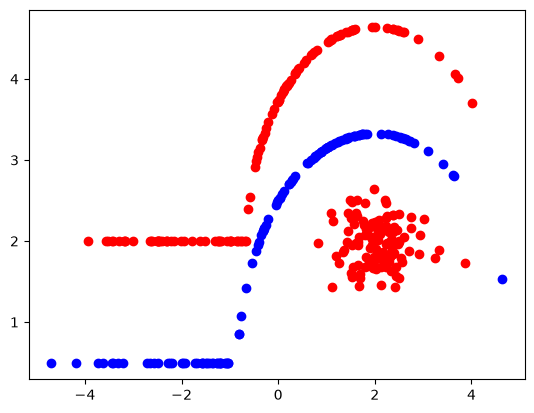

In [60]:
plt.scatter(*data[data['cls'] == 1].values[:, :2].T, c='red')
plt.scatter(*data[data['cls'] == 0].values[:, :2].T, c='blue')
plt.show()

### Train loop

In [68]:
from tqdm.auto import tqdm

In [69]:
n_steps = 1000
lr = 1e-1
model = MLP(d_in=2, d_out=1, d_hidden=10, depth=10)

loss_history = []
for i in tqdm(range(n_steps)):
    x = data[['x', 'y']].values
    y_target = data['cls'].values[:, None]

    y = model(x)
    l, dldy = bce_loss(y, y_target)

    loss_history.append(l.mean())
    model.backward(dldy)
    model.optim_step(lr)

  0%|          | 0/1000 [00:00<?, ?it/s]

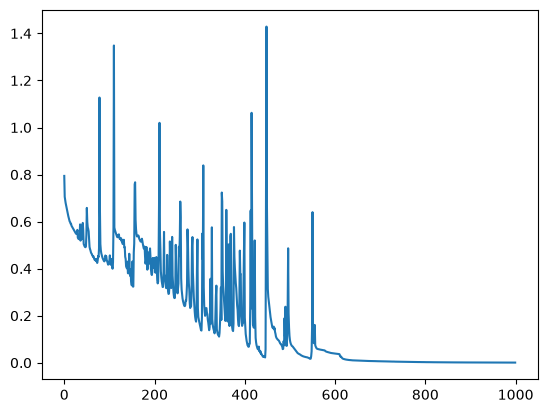

In [73]:
plt.plot(loss_history)
plt.show()

In [71]:
pred = model(data[['x', 'y']].values)

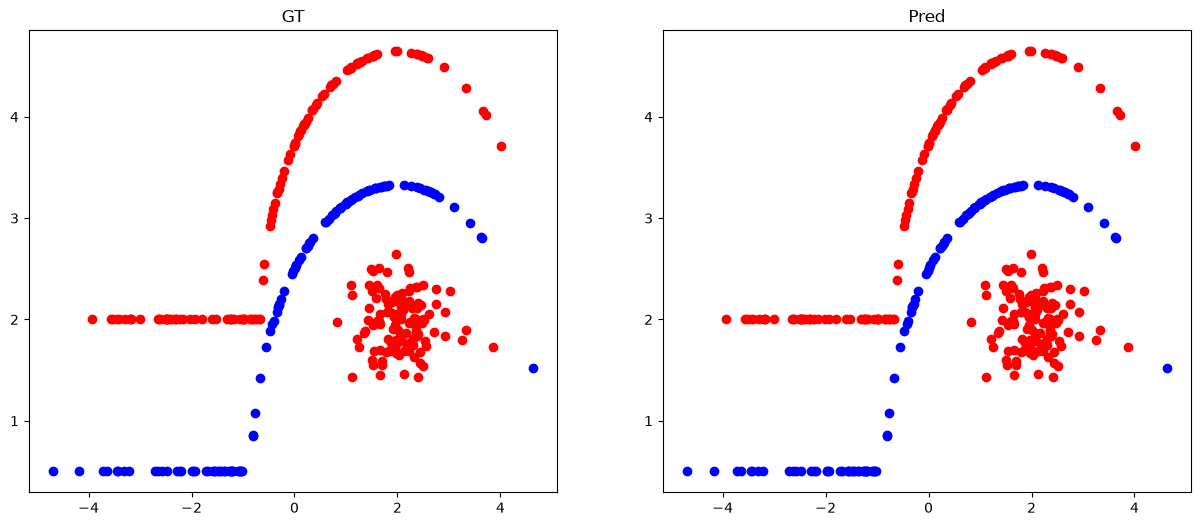

In [72]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

axs[0].scatter(*data[data['cls'] == 1].values[:, :2].T, c='red')
axs[0].scatter(*data[data['cls'] == 0].values[:, :2].T, c='blue')
axs[0].set_title("GT")

axs[1].scatter(*data[pred > 0.5].values[:, :2].T, c='red')
axs[1].scatter(*data[pred <= 0.5].values[:, :2].T, c='blue')
axs[1].set_title("Pred")

plt.show()